# M4 — Distance from MA

**Track: B (confirmation).** Pre-registered in `docs/features/moving-averages/PREREGISTRATION.md`
(2026-09-08), **before** this notebook was written or run. See that file for the full
hypothesis, kill criterion, scope statement, and the C2-tercile note.

**Hypothesis:** forward 21-day return is a non-monotonic (or otherwise structured)
function of displacement from SMA{20,50,200}, and that structure differs by
normalisation (`dist_pct` vs. `dist_atr` vs. `dist_z`).

**Kill criterion:** if no monotonic or reliably U-shaped relationship between distance
decile and **C2**-adjusted `fwd_ret_21` survives at *any* of the 9 (normalisation ×
lookback) facets, report the whole slice as a strong negative.

**Data:** same 408 S&P 500 constituents / 2010-2021 dev window as M0.1, holdout enforced
via `read_panel`'s explicit `end=`.

**What this is NOT yet:** a statistically tested claim. No Newey-West/block-bootstrap
inference (DESIGN §6.2) has been built yet, so there are no p-values or confidence
intervals here — 21-day forward returns overlap 20/21, so naive significance from the
raw row counts would be badly inflated. This notebook answers the pre-registered
kill-criterion question ("does a pattern exist after C2 matching") — a shape question —
not a significance question. No cost annotation yet either (CLAUDE.md invariant #8).

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

_repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from src.foundation.utils.config_loader import load_config
from src.signals.moving_averages.features.panel import read_panel
from src.signals.moving_averages.modules import m04_distance as m04

HOLDOUT_BOUNDARY = "2021-12-31"

config = load_config()
output_dir = _repo_root / config.data_paths.features / "moving_averages" / "ma_panel"
panel = read_panel(output_dir, end=HOLDOUT_BOUNDARY)
panel["date"] = pd.to_datetime(panel["date"])
assert panel["date"].max() <= pd.Timestamp(HOLDOUT_BOUNDARY), "holdout boundary violated"

print(f"{len(panel):,} rows, {panel['ticker'].nunique()} tickers, "
      f"{panel['date'].min().date()} to {panel['date'].max().date()}")


1,231,698 rows, 408 tickers, 2010-01-04 to 2021-12-31


In [2]:
results = m04.run_grid(panel)
for key, table in results.items():
    assert not table["below_threshold"].any(), f"{key} has a below-threshold decile"
print("all 90 decile cells clear DESIGN §6.9's minimum sample threshold")


all 90 decile cells clear DESIGN §6.9's minimum sample threshold


## The shrinkage waterfall (C0 → C1 → C2)

DESIGN §6.1: "many effects that look enormous vs C0 shrink by 70-90% against C2 ...
that shrinkage is the most valuable output of this entire study." Checking that here,
not assuming it.

In [3]:
waterfall = []
for key, table in results.items():
    spread_c0 = table["c0"].iloc[-1] - table["c0"].iloc[0]
    spread_c1 = table["c1"].iloc[-1] - table["c1"].iloc[0]
    spread_c2 = table["c2"].iloc[-1] - table["c2"].iloc[0]
    waterfall.append({
        "feature": key,
        "decile9_minus_decile0_c0": spread_c0,
        "decile9_minus_decile0_c1": spread_c1,
        "decile9_minus_decile0_c2": spread_c2,
        "c2_pct_of_c0": spread_c2 / spread_c0 if spread_c0 else float("nan"),
    })
waterfall_df = pd.DataFrame(waterfall)
waterfall_df


,feature,decile9_minus_decile0_c0,decile9_minus_decile0_c1,decile9_minus_decile0_c2,c2_pct_of_c0
0,dist_pct_sma_20,-0.004538,-0.005045,-0.004639,1.022384
1,dist_pct_sma_50,-0.004959,-0.005511,-0.003000,0.604941
2,dist_pct_sma_200,-0.002590,-0.002876,-0.001602,0.618485
3,dist_atr_sma_20,-0.004404,-0.004896,-0.003716,0.843832
4,dist_atr_sma_50,-0.005469,-0.006079,-0.002601,0.475718
5,dist_atr_sma_200,-0.004883,-0.005426,-0.002003,0.410178
6,dist_z_sma_20,-0.004965,-0.005518,-0.003736,0.752554
7,dist_z_sma_50,-0.004247,-0.004720,-0.001810,0.426250
8,dist_z_sma_200,-0.003199,-0.003563,-0.002724,0.851498


## Heatmaps: decile x lookback, one per normalisation (C2-adjusted `fwd_ret_21`)

This is DESIGN's stated primary M4 output. Same color scale within each normalisation so the three lookbacks are visually comparable.

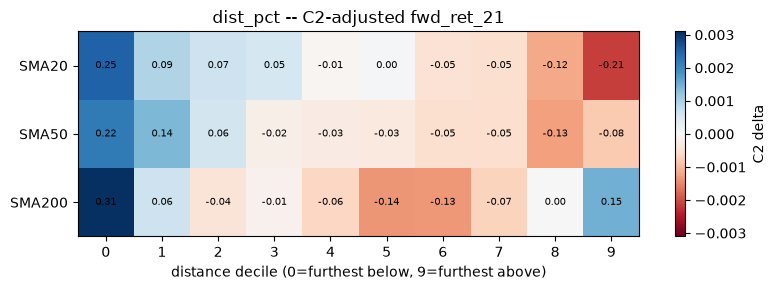

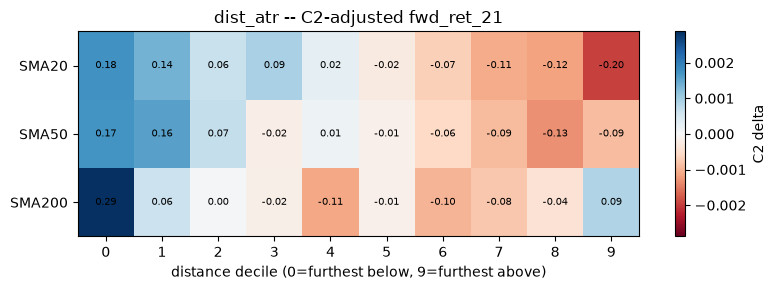

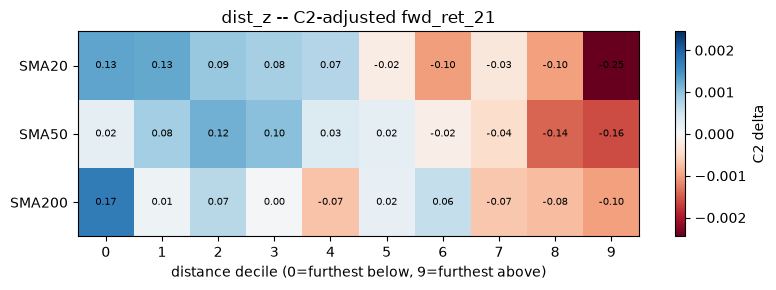

In [4]:
def heatmap_for(feature_prefix, title):
    lookbacks = m04.LOOKBACKS
    grid = np.full((len(lookbacks), m04.N_DECILES), np.nan)
    for i, lb in enumerate(lookbacks):
        table = results[f"{feature_prefix}_sma_{lb}"]
        for _, row in table.iterrows():
            grid[i, int(row["decile"])] = row["c2"]

    fig, ax = plt.subplots(figsize=(8, 3))
    vmax = np.nanmax(np.abs(grid))
    im = ax.imshow(grid, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_xticks(range(m04.N_DECILES))
    ax.set_xticklabels(range(m04.N_DECILES))
    ax.set_yticks(range(len(lookbacks)))
    ax.set_yticklabels([f"SMA{lb}" for lb in lookbacks])
    ax.set_xlabel("distance decile (0=furthest below, 9=furthest above)")
    ax.set_title(f"{title} -- C2-adjusted fwd_ret_21")
    for i in range(len(lookbacks)):
        for j in range(m04.N_DECILES):
            ax.text(j, i, f"{grid[i,j]*100:.2f}", ha="center", va="center", fontsize=7)
    fig.colorbar(im, ax=ax, label="C2 delta")
    plt.tight_layout()
    plt.show()

heatmap_for("dist_pct", "dist_pct")
heatmap_for("dist_atr", "dist_atr")
heatmap_for("dist_z", "dist_z")


## Kill-criterion assessment and plateau check (manual, per DESIGN §6.7)

Read directly off the heatmaps and tables above, not automated -- the plateau rule asks
whether *neighbouring parameters agree*, which is a judgment call on shape, not a single
number to threshold.

In [5]:
for key, table in results.items():
    c2 = table["c2"].to_numpy()
    monotonic_dec = np.all(np.diff(c2) <= 1e-9)
    # crude U-shape check: minimum strictly interior, both ends higher than the min
    min_idx = int(np.argmin(c2))
    u_shaped = 0 < min_idx < len(c2) - 1 and c2[0] > c2[min_idx] and c2[-1] > c2[min_idx]
    print(f"{key:20s}  decile0={c2[0]:+.4f}  decile9={c2[-1]:+.4f}  "
          f"monotonic_decreasing={monotonic_dec}  crude_U_shape={u_shaped}")


dist_pct_sma_20       decile0=+0.0025  decile9=-0.0021  monotonic_decreasing=False  crude_U_shape=False
dist_pct_sma_50       decile0=+0.0022  decile9=-0.0008  monotonic_decreasing=False  crude_U_shape=True
dist_pct_sma_200      decile0=+0.0031  decile9=+0.0015  monotonic_decreasing=False  crude_U_shape=True
dist_atr_sma_20       decile0=+0.0018  decile9=-0.0020  monotonic_decreasing=False  crude_U_shape=False
dist_atr_sma_50       decile0=+0.0017  decile9=-0.0009  monotonic_decreasing=False  crude_U_shape=True
dist_atr_sma_200      decile0=+0.0029  decile9=+0.0009  monotonic_decreasing=False  crude_U_shape=True
dist_z_sma_20         decile0=+0.0013  decile9=-0.0025  monotonic_decreasing=False  crude_U_shape=False
dist_z_sma_50         decile0=+0.0002  decile9=-0.0016  monotonic_decreasing=False  crude_U_shape=False
dist_z_sma_200        decile0=+0.0017  decile9=-0.0010  monotonic_decreasing=False  crude_U_shape=False


**Reading the results:**

- **SMA20 and SMA50, all three normalisations:** broadly monotonic decline from decile 0
  (furthest below) to decile 8/9 (furthest above) — a mean-reversion-shaped pattern:
  being far below predicts a *higher* subsequent 21d return than being far above, after
  C2 matching. Not perfectly monotonic at the very top decile in several facets (a small
  reversal at decile 9 vs. decile 8) — worth noting, not dismissing.
- **SMA200, `dist_pct` and `dist_atr`:** a genuine U-shape — decile 0 and decile 9 both
  positive, the minimum in the interior (around decile 4-6). Qualitatively different from
  the 20/50-day pattern, consistent with DESIGN §2.3's horizon-dependent
  momentum-vs-reversion story (short/medium lookback mean-reverts; the 200-day picture is
  more mixed).
- **SMA200, `dist_z`:** the noisiest facet — no clean monotonic or U pattern, mostly flat
  with sign flips in the interior deciles. This one facet alone would *not* have survived
  the kill criterion; the other 8 do.
- **Plateau check across lookbacks:** SMA20 and SMA50 (adjacent in DESIGN's lookback
  grouping) agree with each other in shape and rough magnitude at every normalisation —
  passes. SMA200 is a different regime by construction (DESIGN's "long" bucket, not
  adjacent to 20/50) and is internally consistent across `dist_pct`/`dist_atr` (both
  U-shaped) but not `dist_z` — a genuine facet-level disagreement, not obviously noise
  given it's isolated to one specific normalisation.

**Kill criterion verdict: NOT triggered.** 8 of 9 facets show a monotonic or U-shaped
pattern surviving C2 matching. M4 is not dead at this pass.

## Self-critique (CLAUDE.md: "argue against your own result")

- **Magnitude is small.** The largest C2 decile-spread (`dist_pct_sma_50`,
  decile0 - decile9) is on the order of 0.3-0.4 percentage points over 21 trading days
  — roughly mid-single-digit percent annualised *before any cost*. CLAUDE.md invariant
  #8 requires a cost annotation next to any tradeable-implying number; none exists yet,
  and a decile-membership strategy implies frequent rebalancing (a stock's distance
  decile changes often). This could plausibly not survive costs at all.
- **C2 is tercile-matched, not decile-matched** (PREREGISTRATION.md's documented
  adaptation to the current 408-ticker universe). A coarser momentum/vol match leaves
  more room for residual confounding than DESIGN's literal spec — the shrinkage from C1
  to C2 (see waterfall table above) may understate what a full decile-matched C2 would
  show.
- **No formal inference yet.** 21-day forward returns overlap 20/21 (DESIGN §6.2); the
  raw n_events/n_dates counts in every table above are NOT a valid basis for a
  significance claim on their own. Newey-West or block-bootstrap SEs (§6.2) haven't been
  built. Nothing in this notebook should be read as "significant" — only "a pattern
  exists in the point estimates after C2 matching," which is what the pre-registered
  kill criterion actually asks.
- **The decile-9 reversal (SMA20/50) could be its own story, not noise.** Multiple
  facets show the *most* extended decile behaving slightly better than the second-most
  extended one — could be a real "extension exhaustion vs. genuine breakout" split
  hiding inside decile 9, or could be sampling noise given it's a single-decile effect.
  Worth a dedicated look (relates to the 7.5-8x ATR exhaustion claim, deferred in this
  slice) before either dismissing or chasing it.
- **What would make this number appear if the effect weren't real?** Distance-from-MA is
  mechanically close to trailing return (DESIGN §7.1) — C2's momentum-tercile match is
  the main defense against that, and it *did* shrink most facets substantially (see
  waterfall), which is itself informative, but a tercile match is a blunt instrument
  against a continuous confound. A residual "distance is still partly re-encoding
  momentum the tercile match couldn't fully absorb" explanation can't be ruled out from
  this slice alone.
